# News Article Grouping Research

In this notebook, we develop and evaluate the **cross-encoder classifier** used in **Stage 2** of the news article grouping research pipeline.

## Cross-Encoder Classifier Development

The objective of this notebook is to train a model capable of **classifying whether a pair of articles refers to the same real-world event**. In this context, *event similarity* does not refer to general semantic similarity, but rather to whether both articles report on **the same underlying real-world occurrence**, potentially from different perspectives or media outlets.

The dataset structure can be represented as:

(A, A₁), (A, A₂), ..., (A, Aₖ) → [1, 0, ..., 1]

where each pair of articles receives a binary label:

- **1** - Both articles refer to the same event  
- **0** - The articles refer to different events

We conduct several experiments to determine which configuration best suits the research objectives, in addition to smaller exploratory experiments performed during development.

1. **Headlines-Only Dataset**  
   This dataset contains pairs of article headlines from approximately **40 news outlets**, with a total of **20,056 examples**. Each example consists of two headlines and a binary label indicating whether the pair refers to the same event.

2. **Headlines + Content Dataset**  
   This dataset follows the same structure as the previous one but also includes the **full article bodies**, providing additional contextual information. It contains **8,284 article pairs**.

3. **Content-Only Dataset**  
   This dataset contains only the **article bodies** for both articles in the pair. The objective of this experiment is to evaluate **how much the headlines contribute to the model's performance**.

4. **Headlines-Only Dataset (~8k)**  
   Although Experiment 1 also uses headlines only, this experiment reduces the dataset size to approximately **8k examples**, matching the size of Experiments 2 and 3. This allows us to evaluate whether **dataset size influences the observed performance differences**.

5. **Post-Hoc Experimentation**  
   In this experiment, we incorporate the **publication date difference between the two articles in a pair** as an additional feature. The intuition is that articles referring to the same event are more likely to be published **close in time**, and therefore this signal may help improve classification performance.

## Experiment Design

### Hypothesis

> Including the **article content** will improve the model's precision, as the additional context may help the model better determine whether two articles describe the same real-world event.

### Pre-processing & Tokenization

Using the **Hugging Face Transformers** library, we convert the raw text into subword tokens compatible with **ModernBERT's vocabulary**. We adopt **ModernBERT** because it represents a significant evolution of the original BERT architecture and was trained on approximately **2 trillion tokens**. Importantly, it natively supports sequences of up to **8,192 tokens**.

> *Note: We experiment with different context lengths to balance computational cost with the ability to capture sufficient article context. Initially, we evaluate sequence lengths between **512 and 2,048 tokens** (depending on the experiment), as the exploratory data analysis (EDA) indicates that most articles fall within this range. Additional experiments with different context sizes may be conducted in future iterations.*

### Fine-Tuning Strategy

Rather than relying on static embeddings, we perform **task-specific fine-tuning** of the model. This allows the model's weights to adapt to the nuances of **news reporting, political language, and framing differences across outlets**.

We experiment with **different numbers of unfrozen layers**, which may influence both training stability and the model's ability to specialize for the **event-matching classification task**.

### Hyperparameter Optimization (HPO)

We conduct hyperparameter searches over key training parameters, focusing primarily on:

- **Learning rate**
- **Weight decay**

The goal is to ensure stable training and optimal convergence for the **article pair classification task**.

### Evaluation & Analysis

Finally, we evaluate the trained models and analyze their performance in order to:

- Identify strengths and weaknesses of each dataset configuration  
- Validate the experimental hypothesis  
- Extract insights that may inform further improvements to the pipeline

## 0. Import Dependencies

In [ ]:
# Install packages needed for HPO + Training
!pip install optuna evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.3 MB/s eta 0:00:00


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import evaluate
import optuna
import torch.nn.functional as F
import seaborn as sns

from datetime import datetime
from datasets import Dataset, DatasetDict
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback
from sklearn.metrics import confusion_matrix, classification_report
from optuna.pruners import MedianPruner
from google.colab import drive

## 0.1 Setup Google Drive

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


### 0.2 Global Variables

In this section, we define the global variables that will be used throughout the notebook. The most important variable is `EXPERIMENT_TYPE`, which determines the execution mode of the notebook.

This variable can take one of two values:

- `headlines` - Processes the **headlines-only dataset**.
- `full` - Processes the dataset that includes **both headlines and article content**.

> *Note: The dataset variations explained in the introduction were done just changing the loaded datasets and the structure is the same in all of them.*

The purpose of this configuration is to make the repository as **reusable and flexible as possible**, allowing the same codebase to be executed with either dataset while requiring minimal modifications.

In [ ]:
# Paths
BASE_DATASET_PATH = "/content/datasets"
MODEL_NAME = "answerdotai/ModernBERT-base"
# Notebook Mode
EXPERIMENT_TYPE = "headlines"

## 1. Datasets Preparation & Pre-Processing

### 1.1 Loading & Transforming Data

In this step, we load the datasets from `.csv` files using **Pandas** and convert them into **Hugging Face `Dataset` objects** for efficient preprocessing and training.

Additionally, we generate a new feature called `diff_days`, which represents the **difference in publication dates between the two articles in each pair**. This feature is used to capture potential temporal proximity between articles that may refer to the same real-world event.

In [ ]:
suffix = "_content" if EXPERIMENT_TYPE == "full" else ""

train_df = pd.read_csv(filepath_or_buffer=f"{BASE_DATASET_PATH}/articles_pairs{suffix}_train.csv")
val_df = pd.read_csv(filepath_or_buffer=f"{BASE_DATASET_PATH}/articles_pairs{suffix}_val.csv")
test_df = pd.read_csv(filepath_or_buffer=f"{BASE_DATASET_PATH}/articles_pairs{suffix}_test.csv")

print(f"Experiment Type: '{EXPERIMENT_TYPE}'")
print(f"Shape of training dataset: {train_df.shape}")
print(f"Shape of validation dataset: {val_df.shape}")
print(f"Shape of testing dataset: {test_df.shape}")

In [ ]:
train_dataset = Dataset.from_pandas(df=train_df.rename(columns={"label": "labels"}))
val_dataset = Dataset.from_pandas(df=val_df.rename(columns={"label": "labels"}))
test_dataset = Dataset.from_pandas(df=test_df.rename(columns={"label": "labels"}))

dataset = DatasetDict()
dataset["train"] = train_dataset
dataset["val"] = val_dataset
dataset["test"] = test_dataset

dataset = dataset.map(lambda x: {
    "diff_days": abs((datetime.strptime(x["date_a"], "%Y-%m-%d") -
                      datetime.strptime(x["date_b"], "%Y-%m-%d")).days)
})

print("Final dataset:\n")
print(dataset)

### 1.2 Tokenization

In this section, we load the **pre-trained tokenizer** corresponding to the transformer model used in our experiments. The tokenizer converts the raw text into subword tokens compatible with the model's vocabulary. We then apply a custom preprocessing function that tokenizes each dataset example, producing the tokenized inputs required for training.

The **maximum sequence length (context size)** differs between the two experimental setups, as the amount of text available in each dataset varies significantly.

For the **headlines-only dataset**, we use a maximum sequence length of **128 tokens**. Since each example contains only `headline_a` and `headline_b`, concatenated using the `[SEP]` token, a large context window is unnecessary. During the exploratory data analysis (EDA), we observed that the longest headline contains **21 words**, meaning that the combined tokenized input typically falls well below the 128-token limit (roughly **60–65 tokens** after tokenization). This configuration avoids excessive padding, reduces computational overhead, and allows faster **hyperparameter optimization (HPO)** and model training while still leaving sufficient margin should slightly longer headlines appear in the future.

For the **headlines + content dataset**, the situation is different. Each example includes the **headlines and the full article bodies for both articles**, which are also concatenated before tokenization. As a result, a substantially larger context window is required. We begin our experiments with a **maximum sequence length of 2,048 tokens**, which allows us to capture the majority of article content while maintaining manageable computational costs.

If the tokenized input exceeds the specified maximum sequence length, the excess tokens are **truncated** during preprocessing.

In [ ]:
print(f"Loading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded sucessfully")

In [ ]:
def tokenize_examples(examples):
    """
    Handles tokenization for both 'headlines' and 'full' experiment types.
    """
    if EXPERIMENT_TYPE == "full":
        text_a = [f"{h} {c}" for h, c in zip(examples["headline_a"], examples["body_a"])]
        text_b = [f"{h} {c}" for h, c in zip(examples["headline_b"], examples["body_b"])]
    else:
        text_a = examples["headline_a"]
        text_b = examples["headline_b"]

    return tokenizer(
        text=text_a,
        text_pair=text_b,
        truncation=True,
        max_length=2048 if EXPERIMENT_TYPE == "full" else 128
    )

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
dataset = dataset.map(tokenize_examples, batched=True, desc="Tokenazing dataset")

## 2. Model Architecture

As introduced earlier in this notebook, we use **ModernBERT**, a pre-trained transformer model from the BERT family, as the backbone of our classifier.

We initially **freeze all pre-trained layers** to preserve the linguistic knowledge learned during large-scale pre-training. We then progressively **fine-tune the model for our specific task** by unfreezing the last *N* transformer layers. This approach allows the upper layers of the network to adapt to the **article pair event-classification task**, while the lower layers retain their general language representations.

> *Architecture Note: For this stage, we do not introduce additional dense layers or custom task-specific heads. Instead, we rely on the **standard sequence classification head provided by the Hugging Face Transformers implementation**, which consists of a linear layer applied to the pooled representation of the transformer output.*

In [ ]:
NUM_LABELS = 2

def init_model():
    """
    Initialices transformer model.
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )

    # Freeze embeddings
    for param in model.model.embeddings.parameters():
        param.requires_grad = False

    # Freeze all layers
    for param in model.model.layers.parameters():
        param.requires_grad = False

    if EXPERIMENT_TYPE == "full":
        # Unfreeze last 2 layers (layers 20-21)
        for param in model.model.layers[20].parameters():
            param.requires_grad = True
        for param in model.model.layers[21].parameters():
            param.requires_grad = True
    else:
        # Unfreeze last 3 layers (layers 19-20-21)
        for param in model.model.layers[19].parameters():
            param.requires_grad = True
        for param in model.model.layers[20].parameters():
            param.requires_grad = True
        for param in model.model.layers[21].parameters():
            param.requires_grad = True

    # Unfreeze the head and classifier (always trainable for fine-tuning)
    for param in model.head.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    print(f"Sucessfully initialized `{MODEL_NAME}` model")
    model.resize_token_embeddings(len(tokenizer))

    return model

> *Note: The number of unfrozen layers differs between the two datasets. For the **headlines-only dataset**, we unfreeze **3 transformer layers**, as it contains more than twice the number of training examples compared to the second dataset. For the **headlines + content dataset**, which contains approximately **8k examples**, we unfreeze **2 layers**. This strategy aims to reduce the risk of **overfitting**, as fine-tuning too many parameters on a smaller dataset may lead the model to over-adapt to the training data.*

In [ ]:
# Temporal instance of the model to check parameters count
temp_model = init_model()

total_params = sum(p.numel() for p in temp_model.parameters())
trainable_params = sum(p.numel() for p in temp_model.parameters() if p.requires_grad)

print("Model Parameters Count:")
print(f"Total: {total_params}")
print(f"Trainable: {trainable_params}")
print(f"Frozen: {total_params - trainable_params}")

del temp_model

**Headline-Only Model**
| Parameter Type | Number of Parameters |
| -------------- | -------------------- |
| **Total**      | 149,606,402          |
| **Trainable**  | 15,638,018           |
| **Frozen**     | 133,968,384          |

<br/>

**Headline + Content Model**
| Parameter Type | Number of Parameters |
| -------------- | -------------------- |
| **Total**      | 149,606,402          |
| **Trainable**  | 10,622,978           |
| **Frozen**     | 138,983,424          |


## 3. Hyperparameter Optimization (HPO) + Training

### Evaluation Metrics

Since both datasets exhibit a **significant class imbalance**, our evaluation will focus primarily on the **F1-score**, which balances **precision** and **recall** and provides a more informative measure of performance than accuracy in imbalanced classification settings.

In addition to the F1-score, we also report **precision** and **recall** to better understand the model's behavior when identifying article pairs that refer to the same event.

In [ ]:
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    """
    Computes metrics for our transformer model. It uses a combination of 'precision', 'recall' and 'f1' metrics.

    Args:
        eval_pred (): Predictions.

    Returns:
        Dictionary containing the metrics.
    """
    # Destructure logits and labels
    logits, labels = eval_pred
    # Generate predictions
    predictions = np.argmax(logits, axis=-1)

    results = {}
    results.update(precision.compute(predictions=predictions, references=labels, average="weighted"))
    results.update(recall.compute(predictions=predictions, references=labels, average="weighted"))
    results.update(f1.compute(predictions=predictions, references=labels, average="weighted"))

    return results

### Custom Loss Function

Since our dataset exhibits **class imbalance**, we implement a **custom loss function** to better account for the minority class during training. This is achieved by creating a subclass of the Hugging Face `Trainer` and overriding the `compute_loss` method.

Through this approach, we apply **class weighting**, assigning a higher weight to the minority class so that misclassifications of positive examples are penalized more strongly during optimization.

In [ ]:
class CustomLossTrainer(Trainer):
    def __init__(self, *args, loss_fn=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = loss_fn

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss = self.loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
def focal_loss(logits, labels, gamma=2.0):
    alpha = torch.tensor([0.18, 0.82]).to(logits.device)
    ce_loss = F.cross_entropy(logits, labels, reduction="none")
    pt = torch.exp(-ce_loss)
    alpha_t = alpha[labels]
    loss = (alpha_t * (1 - pt) ** gamma * ce_loss).mean()

    return loss

### HPO + Trainer Setup

We will first create the default `TrainingArguments` for our model that will be use to find the optimal hyperparameters using `.hyperparameter_search()`. Once we find the best for our scenario, we will train the final fine-tuned version of our model.

**Primary Hyperparameters**

* Learning Rate (learning_rate) - Controls the step size during gradient descent, between 1e-5 to 5e-5 (log scale).

* Training Epochs (num_train_epochs) - Number of complete passes through the training dataset, between 1 and 5.

* Batch Size (per_device_train_batch_size) - Number of samples processed together in one forward/backward pass, range: [16, 32].

**Secondary Hyperparameters (Optional)**

* Warmup Ratio (warmup_ratio) - Fraction of training steps to gradually increase learning rate, between 0.05 and 0.15.

* Weight Decay (weight_decay) - L2 regularization to prevent overfitting, between 1e-3 to 1e-1.

* Gradient Accumulation (gradient_accumulation_steps) - Simulate larger batch sizes by accumulating gradients, range: [1, 2].

In [ ]:
def objective(trial):
    """
    Optuna's objective function to create possible hyperparameters to search.
    """
    training_args = TrainingArguments(
        output_dir=f"./hpo_results/trial_{trial.number}",
        num_train_epochs=3,
        max_steps=1000,
        eval_strategy="steps",
        eval_steps=50,
        save_strategy="steps",
        save_steps=50,
        load_best_model_at_end=True,
        save_total_limit=1,
        per_device_train_batch_size=trial.suggest_categorical("train_bs", [16, 32]),
        gradient_accumulation_steps=trial.suggest_categorical("grad_accum", [1, 2]),
        learning_rate=trial.suggest_float("lr", 1e-5, 5e-5, log=True),
        weight_decay=trial.suggest_float("weight_decay", 1e-3, 1e-1, log=True),
        warmup_ratio=trial.suggest_float("warmup_ratio", 0.05, 0.15),

        metric_for_best_model="f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        bf16=True,
        dataloader_num_workers=2,
    )

    trainer = CustomLossTrainer(
        model_init=init_model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["val"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        loss_fn=focal_loss,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
    )

    trainer.train()
    metrics = trainer.evaluate()

    return metrics["eval_f1"]

### Setup HPO Tracking

In [ ]:
DB_DIR = "/content/drive/MyDrive/Research/articles_grouping/hpo_full"
os.makedirs(DB_DIR, exist_ok=True)

db_path = f"sqlite:///{DB_DIR}/optuna.db"

if os.path.exists(f"{DB_DIR}/optuna.db"):
    print(f"Optuna database found at {DB_DIR}/optuna.db. Attempting to load existing study.")
else:
    print(f"Optuna database not found at {DB_DIR}/optuna.db. A new study will be created.")

### Run HPO study

In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=100, interval_steps=100),
    storage=db_path,
    load_if_exists=True,
)

NUM_TRIALS = 10
study.optimize(objective, n_trials=NUM_TRIALS)

### HPO Results

#### 1. Headlines-Only Dataset

**Best F1-Score:** 0.9115

| Hyperparameter | Value |
|----------------|------|
| Train Batch Size | 32 |
| Gradient Accumulation | 2 |
| Learning Rate | 3.538461259525519e-05 |
| Weight Decay | 0.002508115686045232 |
| Warmup Ratio | 0.10142344384136115 |

> *Note: This HPO ran on a NVIDIA L4 with 22.5GB of vram and 53GB of system ram.*

<br/>

#### 2. Headlines + Content Dataset

**Best F1-Score:** 0.8560

| Hyperparameter | Value |
|----------------|------|
| Train Batch Size | 32 |
| Gradient Accumulation | 2 |
| Learning Rate | 4.221409440229581e-05 |
| Weight Decay | 0.015696396388661146 |
| Warmup Ratio | 0.14218742350231167 |

> *Note: This HPO ran on a NVIDIA L4 with 22.5GB of vram and 53GB of system ram.*

## 4. Model Evaluation

Using the hyperparameters obtained from the **best trial during hyperparameter optimization (HPO)**, we train a final version of the model and evaluate its performance on the evaluation dataset.

In addition, we conduct **error analysis** to better understand the types of mistakes made by the model and to identify potential areas for improvement in future iterations.

In [ ]:
if EXPERIMENT_TYPE == "full":
    best_hyperparameters = {
        "num_train_epochs": 2,
        "train_bs": 32,
        "eval_bs": 32,
        "grad_accum": 2,
        "lr": 4.221409440229581e-05,
        "weight_decay": 0.015696396388661146,
        "warmup_ratio": 0.14218742350231167,
    }
else:
    best_hyperparameters = {
        "num_train_epochs": 2,
        "train_bs": 32,
        "eval_bs": 64,
        "grad_accum": 2,
        "lr": 3.538461259525519e-05,
        "weight_decay": 0.002508115686045232,
        "warmup_ratio": 0.10142344384136115,
    }

In [ ]:
# Setup final training parameters
final_training_params = {
    "num_train_epochs": best_hyperparameters["num_train_epochs"],
    "learning_rate": best_hyperparameters["lr"],
    "per_device_train_batch_size": best_hyperparameters["train_bs"],
    "gradient_accumulation_steps": best_hyperparameters["grad_accum"],
    "per_device_eval_batch_size": best_hyperparameters["eval_bs"],
    "weight_decay": best_hyperparameters["weight_decay"],
    "warmup_ratio": best_hyperparameters["warmup_ratio"],
}

final_training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    max_steps=-1,

    num_train_epochs=final_training_params["num_train_epochs"],
    learning_rate=final_training_params["learning_rate"],
    per_device_train_batch_size=final_training_params["per_device_train_batch_size"],
    gradient_accumulation_steps=final_training_params["gradient_accumulation_steps"],
    per_device_eval_batch_size=final_training_params["per_device_eval_batch_size"],
    weight_decay=final_training_params["weight_decay"],
    warmup_ratio=final_training_params["warmup_ratio"],

    logging_steps=100,
    save_total_limit=2,
    bf16=True
)

# Create final trainer instance
final_trainer = CustomLossTrainer(
    model_init=init_model,
    args=final_training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["val"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    loss_fn=focal_loss
)

# Train final model
final_trainer.train()
# Evaluate final model
test_results = final_trainer.evaluate(dataset["test"])

In [ ]:
predictions_output = final_trainer.predict(dataset["test"])

y_true = predictions_output.label_ids
logits = torch.tensor(predictions_output.predictions)
probs = torch.softmax(logits, dim=-1)[:, 1]

diff_days = torch.tensor(dataset["test"]["diff_days"], dtype=torch.float32)

BEST_LAMBDA = 0.20
BEST_THRESHOLD = 0.45

adjusted_probs = probs * torch.exp(-BEST_LAMBDA * diff_days)
y_pred = (adjusted_probs >= BEST_THRESHOLD).long().numpy()

print(classification_report(y_true, y_pred, target_names=["Different Event", "Same Event"]))

### 4.1 Evaluation Results

#### 1. Headlines-Only Dataset

During the first inference evaluation using the fine-tuned model, the results showed that the model performed well overall but struggled with **false positives**. For our task, minimizing false positives is particularly important: misclassifying two articles as belonging to the same event when they do not is more problematic for the downstream pipeline than failing to group two articles that actually refer to the same event.

To address this issue, we increased the **classification threshold to 0.55** after performing a threshold sweep to determine the most suitable value. After re-running inference with this updated threshold, the model achieves a **Same Event precision of 0.74** and **recall of 0.72**. This represents a significant reduction in false positives (**164 → 90**) compared to the default threshold of **0.50**, at the cost of a moderate increase in false negatives (**79 → 97**).

Overall **accuracy reaches 91%**, with a **weighted F1-score of 0.91**.

These results establish the **headlines-only baseline (Experiment 1)**. In **Experiment 2**, we evaluate whether incorporating the **full article content** improves the model's ability to distinguish between articles that refer to the same real-world event and those that do not.

<br/>

| Metric | Value |
|------|------|
| Eval Loss | 0.02614 |
| Precision | 0.8927 |
| Recall | 0.8789 |
| F1-Score | 0.8838 |
| Epoch | 2 |

<br/>

| Class | Precision | Recall | F1-Score | Support |
|------|------|------|------|------|
| Different Event | 0.94 | 0.95 | 0.94 | 1656 |
| Same Event | 0.74 | 0.72 | 0.73 | 350 |
| **Accuracy** | — | — | **0.91** | 2006 |
| **Macro Avg** | 0.84 | 0.83 | 0.84 | 2006 |
| **Weighted Avg** | 0.91 | 0.91 | 0.91 | 2006 |

<br/>

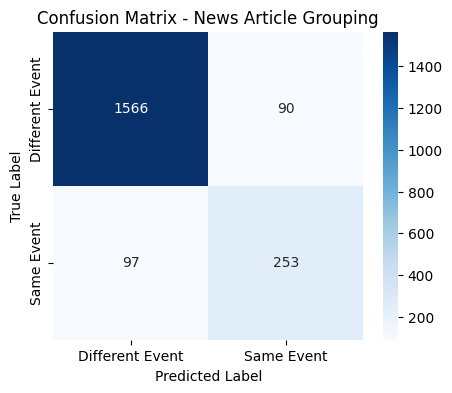

<br/>

---

<br/>

#### 2. Headlines + Content Dataset

When including the **full article content**, the model performs worse than in the headlines-only experiment. This suggests that the additional content introduces **noise** rather than useful signal for this classification task.

| Metric | Value |
|------|------|
| Eval Loss | 0.04280 |
| Precision | 0.8125 |
| Recall | 0.7829 |
| F1-Score | 0.7946 |
| Epoch | 3 |

<br/>

| Class | Precision | Recall | F1-Score | Support |
|------|------|------|------|------|
| Different Event | 0.88 | 0.93 | 0.90 | 679 |
| Same Event | 0.56 | 0.42 | 0.48 | 150 |
| **Accuracy** | — | — | **0.84** | 829 |
| **Macro Avg** | 0.72 | 0.67 | 0.69 | 829 |
| **Weighted Avg** | 0.82 | 0.84 | 0.83 | 829 |

<br/>

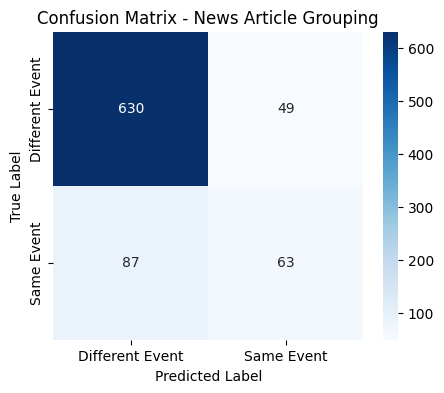

<br/>

---

<br/>

#### 3. Content-Only Dataset

This experiment produced significantly worse results than Experiment 2, achieving an **F1-score of 0.41**. This strongly suggests that the model relies heavily on **headline information** when determining whether two articles refer to the same event.

<br/>

---

<br/>

#### 4. Headlines-Only Dataset (~8k)

This experiment produced **very similar results to Experiment 1**, with the F1-score decreasing by only **0.04**. This indicates that the performance difference observed in Experiment 2 is **not primarily caused by dataset size**, but rather by the **additional noise introduced by the article content**.

<br/>

---

<br/>

#### 5. Post-Hoc Experimentation

Finally, we introduced an additional feature representing the **publication date difference between the two articles in a pair**. Incorporating this temporal signal improved the model's ability to correctly identify same-event pairs.

| Class | Precision | Recall | F1-Score | Support |
|------|------|------|------|------|
| Different Event | 0.95 | 0.95 | 0.95 | 1656 |
| Same Event | 0.75 | 0.76 | 0.76 | 350 |
| **Accuracy** | — | — | **0.92** | 2006 |
| **Macro Avg** | 0.85 | 0.86 | 0.85 | 2006 |
| **Weighted Avg** | 0.92 | 0.92 | 0.92 | 2006 |

<br/>

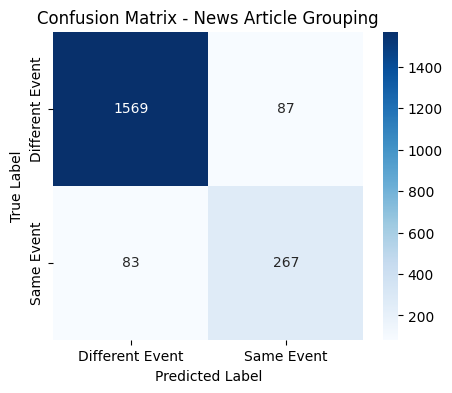


---

# Conclusion

After running all experiments and dataset variations, including:

- **Headlines-Only dataset (~20k samples)**
- **Headlines + Content dataset (~8k samples)**
- **Content-Only dataset (~8k samples)**
- **Headlines-Only dataset reduced to ~8k samples** to evaluate whether dataset size affected performance

Additionally, we conducted **post-hoc experimentation** by incorporating the **date difference between article pairs** as an additional feature.

From these experiments, we conclude that the **most effective approach for this task is to use only article headlines**. In both experiments that incorporated full article content, the results were significantly worse, with performance dropping by **approximately 50%** compared to the headlines-only models. This suggests that the article content introduced **noise rather than useful signals** for the model.

> **Note:** This outcome may be explained by two factors. First, article content may inherently be less informative for this specific task compared to headlines. Second, the **quality of the content data** may not be optimal. For this reason, we do not completely discard the possibility of revisiting this part of the research pipeline in the future using a **different dataset with higher-quality content**, ideally **hand-annotated and composed of more recent articles**.

Based on these results, we determined that the **headlines-only configuration provides the best balance between performance and robustness**. While this setup already produced strong results, the **post-hoc experimentation using the article date difference** further improved performance. This modification resulted in an **additional improvement of approximately 0.03 (3%) in F1-score**. Although this increase may appear modest, it is significant given the already high baseline performance.

Importantly, this improvement not only increased the overall evaluation metrics but also **reduced both false positives and false negatives**, leading to higher numbers of **true positives and true negatives**.

In conclusion, the **fine-tuned transformer model trained on headlines, combined with the post-hoc date difference feature**, represents the most effective configuration identified in this study. This model will therefore be used in **Stage 2, Part 1 of the news article grouping research pipeline**.